## 1. What this notebook computes

Notebook 16a ran the reference solver as a finished program. This notebook opens
it up and rebuilds its method by hand on the one problem whose answers are known
exactly: the **free** orbital equation (no interaction, $\lambda = 0$) with zero
3-momentum ($k = 0$) and constant mass $M = m = 1$. Step by step it

- derives the exact levels of that problem (and checks the derivation with sympy);
- places the two components of an orbital on a **staggered grid** and turns the
  differential equation into a **symmetric tridiagonal matrix**, and checks that
  the matrix is exactly the one the reference program builds;
- finds the eigenvalues by **Sturm counts** and **bisection**, the method of the
  reference, and checks them against a standard eigenvalue routine;
- constructs the **exact zero mode** of the discrete problem by hand;
- treats the odd parity with the reference's **rotated frame**;
- shows on five grids that the error shrinks like $h^2$ and that two
  **Richardson** steps remove it down to rounding;
- computes the slope of the **brane band** at the five slices of the deflating
  history and compares it with the exact formula of `ks-theory.json`;
- runs the reference program's own free-field job again and checks that it
  reproduces the committed record and passes the six free-field checks.

It draws seven figures and runs in less than a minute.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 16b (The reference method by hand: staggered grid, Sturm counts, Richardson) is
the file `Revision/textbook/notebooks/16b_staggered_grid.ipynb` of the repository
Dirac_claude. It builds, line by line, the staggered finite-difference matrix that the
independent reference solver uses, for the free Kohn-Sham orbital equation at zero
3-momentum, a problem whose levels are known exactly; it finds the levels by Sturm counts
and bisection, shows that the grid error shrinks like the square of the cell width and
that two Richardson steps remove it, constructs the exact discrete zero mode at the
brane, computes the slope of the brane band at the five slices of the deflating history,
and checks every number against the committed record of the reference solver, whose
free-field checks it also runs again. It needs a computer with Windows 11, macOS or
Linux, an internet connection for the installation, the program Git, and Python 3.12 or
newer (the notebooks were built with Python 3.14.5) with these packages at exactly these
versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab 4.4.10,
nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The notebook
itself imports numpy, sympy and matplotlib; the other packages run Jupyter, the program
that shows and runs notebooks. It does not need Rust.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (a few hundred megabytes; the folder then
needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
folder, create a private Python environment in the folder dirac-book-env inside your home
folder (a private environment is a folder with its own copy of Python and of the
packages, so that nothing else on your computer is changed), activate it (from then on
the commands `python` and `jupyter` typed in this terminal are those of the environment,
and the prompt starts with (dirac-book-env)), and install the packages at the pinned
versions (this downloads about 90 MB and takes a few minutes; the environment takes about
400 MB of disk space). If you have done this step before, for this or for another
notebook, skip it and go to Step 4; to get the newest version of the repository, run `git
pull` in the repository folder after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 16b_staggered_grid.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 45 seconds on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 6. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 16b_staggered_grid.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
16b_staggered_grid.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 7. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/16b.captions.json`
- `Revision/textbook/figures/16b_1_staggered_grid.png`
- `Revision/textbook/figures/16b_2_sturm_staircase.png`
- `Revision/textbook/figures/16b_3_orbitals.png`
- `Revision/textbook/figures/16b_4_matrix_heat_maps.png`
- `Revision/textbook/figures/16b_5_convergence_ladder.png`
- `Revision/textbook/figures/16b_6_error_ratios.png`
- `Revision/textbook/figures/16b_7_brane_band_slope.png`

It changes no other file of the repository; running it headless or saving it in
JupyterLab also rewrites the notebook file itself. It does not use the internet while it
runs. The files it writes are the same files that are stored in the repository (on
another computer a figure may differ in a few bytes, which is harmless). To get the
stored versions back, run this command in the repository folder (it also undoes every
change you made yourself in the folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 31 CHECKS PASSED (notebook 16b)

and the notebook must show 7 figures below the cells that draw them.

**Step 8. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/16b_staggered_grid.ipynb` inside the folder Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- The cell that computes the levels on five grids runs for a minute or longer: this is
  normal on a slow computer: the Sturm count is a loop over up to 4799 matrix rows,
  repeated about 60 times for every grid. Wait until the label shows a number.
- An AssertionError names a comparison with the record free-checks.json: the reference
  program or its record was changed. Get the stored versions back and run the notebook
  again.

      git checkout -- Revision/kohn_sham

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 16b (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 16b (The reference method by hand: staggered grid, Sturm counts, Richardson)
# is the file Revision/textbook/notebooks/16b_staggered_grid.ipynb of the repository
# Dirac_claude. It builds, line by line, the staggered finite-difference matrix that the
# independent reference solver uses, for the free Kohn-Sham orbital equation at zero
# 3-momentum, a problem whose levels are known exactly; it finds the levels by Sturm
# counts and bisection, shows that the grid error shrinks like the square of the cell
# width and that two Richardson steps remove it, constructs the exact discrete zero mode
# at the brane, computes the slope of the brane band at the five slices of the deflating
# history, and checks every number against the committed record of the reference solver,
# whose free-field checks it also runs again. It needs a computer with Windows 11, macOS
# or Linux, an internet connection for the installation, the program Git, and Python 3.12
# or newer (the notebooks were built with Python 3.14.5) with these packages at exactly
# these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib 3.11.0, jupyterlab
# 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and nbconvert 7.16.6. The
# notebook itself imports numpy, sympy and matplotlib; the other packages run Jupyter,
# the program that shows and runs notebooks. It does not need Rust.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (a few hundred megabytes; the folder then
# needs up to about 1 GB of disk space) into the folder Dirac_claude inside your home
# folder, create a private Python environment in the folder dirac-book-env inside your
# home folder (a private environment is a folder with its own copy of Python and of the
# packages, so that nothing else on your computer is changed), activate it (from then on
# the commands python and jupyter typed in this terminal are those of the environment,
# and the prompt starts with (dirac-book-env)), and install the packages at the pinned
# versions (this downloads about 90 MB and takes a few minutes; the environment takes
# about 400 MB of disk space). If you have done this step before, for this or for another
# notebook, skip it and go to Step 4; to get the newest version of the repository, run
# git pull in the repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 16b_staggered_grid.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 45
# seconds on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 6. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 16b_staggered_grid.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 16b_staggered_grid.ipynb (in the same folder, without running the cells again) to read
# the printed lines and see the figures.
#
# STEP 7. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/16b.captions.json
# - Revision/textbook/figures/16b_1_staggered_grid.png
# - Revision/textbook/figures/16b_2_sturm_staircase.png
# - Revision/textbook/figures/16b_3_orbitals.png
# - Revision/textbook/figures/16b_4_matrix_heat_maps.png
# - Revision/textbook/figures/16b_5_convergence_ladder.png
# - Revision/textbook/figures/16b_6_error_ratios.png
# - Revision/textbook/figures/16b_7_brane_band_slope.png
#
# It changes no other file of the repository; running it headless or saving it in
# JupyterLab also rewrites the notebook file itself. It does not use the internet while
# it runs. The files it writes are the same files that are stored in the repository (on
# another computer a figure may differ in a few bytes, which is harmless). To get the
# stored versions back, run this command in the repository folder (it also undoes every
# change you made yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 31 CHECKS PASSED (notebook 16b)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 8. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/16b_staggered_grid.ipynb inside the folder Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - The cell that computes the levels on five grids runs for a minute or longer: this is
#   normal on a slow computer: the Sturm count is a loop over up to 4799 matrix rows,
#   repeated about 60 times for every grid. Wait until the label shows a number.
# - An AssertionError names a comparison with the record free-checks.json: the reference
#   program or its record was changed. Get the stored versions back and run the notebook
#   again.
#     git checkout -- Revision/kohn_sham
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell

NOTEBOOK_ID = "16b"  # this notebook: chapter 16, example b


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 16b complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Orbital**: a one-particle wave function; here a pair of real functions $a(y)$,
  $b(y)$ of the hidden coordinate $y$ in $-L \le y \le 0$ ($L = 3$).
- **Level**: an allowed energy $\varepsilon$ of the orbital equation.
- **Exact** (or analytic) **value**: a number obtained by algebra, without a grid.
- **Grid**: the points that divide $-L \le y \le 0$ into $G$ equal **cells** of
  width $h = L/G$. **Nodes** are the cell ends $y_i = -L + i\,h$
  ($i = 0, \dots, G$), **half nodes** the cell centres
  $y_{p+1/2} = -L + (p + \tfrac12)\,h$ ($p = 0, \dots, G - 1$).
- **Staggered grid**: $a$ is stored at the half nodes, $b$ at the nodes.
- **Matrix** $T$: a square table of numbers; **symmetric**: $T_{rc} = T_{cr}$;
  **tridiagonal**: only the main diagonal and its two neighbours are not zero.
- **Eigenvalue** and **eigenvector**: a number $\varepsilon$ and a column $z \ne 0$
  with $T z = \varepsilon z$. A symmetric matrix of size $n$ has $n$ real
  eigenvalues.
- **Sturm count** $c(x)$: the number of eigenvalues of $T$ below a number $x$.
- **Bisection**: halving an interval that contains the wanted value until it is
  small enough.
- **Order of convergence**: the power $q$ in an error $\approx C h^q$; the reference
  has $q = 2$.
- **Richardson extrapolation**: a combination of results on several grids in which
  the leading errors cancel.
- **Machine epsilon** $\epsilon_{mach} = 2^{-52} \approx 2.2\times10^{-16}$: the
  relative size of the rounding error of one operation in the computer's numbers.
- **Parity**: the condition at the brane $y = 0$: **even** $b(0) = 0$, **odd**
  $a(0) = 0$ (the ASSUMED $Z_2$ brane). **Block type** $j = \pm 1$: the two kinds of
  $2\times 2$ blocks.
- **Zero mode**: a level with $\varepsilon = 0$ exactly.
- **Brane band**: the lowest even levels at small 3-momentum $k$, whose orbitals sit
  at the brane; its **slope** is $d\varepsilon/dk$ at $k = 0$.

## 4. The physical and mathematical situation

The Kohn-Sham orbitals of dirac16complex in the author's primordial field depend on
the hidden coordinate $y = \ln(\sin z)/(6H)$ (with $z = 6Hx_8$; $y = 0$ is the brane,
$y = -L$ the tip). With $\chi = (a, i\,b)$ the block equation of `ks-theory.json`
(entry `blockEquation.realForm`) reads, for the free problem ($v = 0$, constant
$M$), units $H = m = 1$:
$$a' = M a - \left(\kappa k + j\varepsilon\right) b, \qquad
b' = \left(j\varepsilon - \kappa k\right) a - M b,$$
where $' = d/dy$, $\kappa = e^{-Hy - a_{4,0}}$ and $k$ is the size of the 3-momentum.
Here $\kappa$ is one over the 3-space scale factor $e^{a_4}\sin^{1/6} z = e^{a_4 + Hy}$:
along the history $a_4$ grows, 3-space inflates, the three extra times
$x_5, x_6, x_7$ deflate with $e^{-a_4}$, and the 3-momenta are redshifted by
$e^{-a_{4,0}}$. The boundary conditions are the regular tip $b(-L) = 0$ (chosen)
and the ASSUMED $Z_2$ brane: $b(0) = 0$ for even and $a(0) = 0$ for odd orbitals.

For $k = 0$ the momentum term drops out, $\kappa$ disappears, and the levels are known
exactly. That makes this problem the reference solver's test bench: every error of
the grid can be measured against the exact answer. The interacting states of the
canonical matrix (Notebook 16a) use the same matrix with $k \ne 0$ and
self-consistent $M(y)$ and $v(y)$, where no exact answer exists.

## 5. The exact levels, line by line

**Even parity** ($b(-L) = 0$ and $b(0) = 0$), $k = 0$, $j^2 = 1$:

- The second equation $b' = j\varepsilon a - M b$ gives
  $a = j\,(b' + M b)/\varepsilon$ for $\varepsilon \ne 0$ (multiply by $j$ and use
  $j^2 = 1$).
- Put this $a$ into the first equation $a' = M a - j\varepsilon b$:
  $j(b'' + M b')/\varepsilon = M j (b' + M b)/\varepsilon - j\varepsilon b$.
- Multiply by $\varepsilon/j$: $b'' + M b' = M b' + M^2 b - \varepsilon^2 b$.
- Cancel $M b'$: $b'' = -(\varepsilon^2 - M^2)\,b$.
- With $p^2 = \varepsilon^2 - M^2 > 0$ the solution with $b(-L) = 0$ is
  $b = \sin(p\,(y + L))$ (a sine that starts at zero at the tip).
- $b(0) = 0$ needs $\sin(pL) = 0$, so $p = n\pi/L$ with $n = 1, 2, \dots$, and
  $\varepsilon = \pm\sqrt{M^2 + (n\pi/L)^2}$.

**The zero mode** ($\varepsilon = 0$): the equations become $a' = M a$ and
$b' = -M b$, so $a = A\,e^{My}$ and $b = B\,e^{-My}$; $b(-L) = 0$ forces $B = 0$.
So $b = 0$ everywhere and $a = A\,e^{My}$, a mode that grows towards the brane. With
$\int_{-L}^{0} a^2\,dy = 1$ we get $A^2 (1 - e^{-2ML})/(2M) = 1$, so
$A = \sqrt{2M/(1 - e^{-2ML})}$.

**Odd parity** ($b(-L) = 0$ and $a(0) = 0$): again $b = \sin(p\,(y+L))$, and then
$a = j\,(p\cos(p\,(y+L)) + M \sin(p\,(y+L)))/\varepsilon$. The condition $a(0) = 0$
is $p\cos(pL) + M\sin(pL) = 0$, that is $\tan(pL) = -p/M$, with one root $p_l$ in
each interval $((l + \tfrac12)\pi/L, (l+1)\pi/L)$, $l = 0, 1, 2, \dots$, and
$\varepsilon = \pm\sqrt{M^2 + p_l^2}$. These are the formulas of `ks-theory.json`,
entry `boundaryConditions.exactK0Spectra`.

**Odd parity has no level with $\varepsilon^2 \le M^2$**, so all its levels have
$|\varepsilon| > M$:
- $\varepsilon = 0$: as for the zero mode, $a = A\,e^{My}$ and $b = 0$; then
  $a(0) = A = 0$, so only the trivial solution $a = b = 0$ is left: no zero mode.
- $0 < \varepsilon^2 < M^2$: now $b'' = q^2 b$ with $q^2 = M^2 - \varepsilon^2 > 0$,
  and the solution with $b(-L) = 0$ is $b = \sinh(q\,(y+L))$; then
  $a(0) = j\,(q\cosh(qL) + M\sinh(qL))/\varepsilon$, which is not 0, because both
  terms in the bracket are positive.
- $\varepsilon^2 = M^2$: now $b'' = 0$, so $b = y + L$, and
  $a(0) = j\,(1 + ML)/\varepsilon$, again not 0.

**Ranks.** The levels of a sector are counted from the lowest **particle** level
(rank 0): for even parity that is the zero mode (by the convention of
`ks-theory.json`, the brane zero modes are particles), then $n = 1, 2, \dots$ are
ranks $1, 2, \dots$ and the negative levels are ranks $-1, -2, \dots$; for odd parity
rank $r \ge 0$ is $+\sqrt{M^2 + p_r^2}$ and rank $-r-1$ is its negative.

The next cell checks the two solutions with sympy (it substitutes them into both
equations and simplifies the residuals to zero) and computes the exact levels of
ranks $-3$ to $5$ for $M = 1$, $L = 3$, finding the odd roots by bisection.

In [2]:
import math  # functions of single numbers (sqrt, sin, pi, ...)
import sys  # the list of folders in which Python looks for modules

import numpy as np  # arrays of numbers
import sympy as sp  # exact symbolic algebra

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
           "#4a3aa7", "#e34948"]  # the colours of the figures, in a fixed order
M_VALUE, L_VALUE = 1.0, 3.0  # the mass M = m = 1 and the tip cutoff L = 3

y, p, eps = sp.symbols("y p epsilon", real=True)  # real symbols
M, L = sp.symbols("M L", positive=True)  # M > 0 and L > 0 (needed by the integral)
for j_value in (1, -1):
    j = sp.Integer(j_value)
    b = sp.sin(p * (y + L))  # the even and odd solution for b
    a = j * (sp.diff(b, y) + M * b) / eps  # a from the second equation
    on_shell = {eps: sp.sqrt(M ** 2 + p ** 2)}  # epsilon^2 = M^2 + p^2
    first = sp.diff(a, y) - (M * a - j * eps * b)  # a' - (M a - j eps b)
    second = sp.diff(b, y) - (j * eps * a - M * b)  # b' - (j eps a - M b)
    residuals = [sp.simplify(r.subs(on_shell)) for r in (first, second)]
    check(residuals == [0, 0],
          f"sympy: b = sin(p(y+L)), a = j(b' + M b)/eps solve both equations (j = "
          f"{j_value}) when eps^2 = M^2 + p^2")
zero_a = sp.exp(M * y)  # the zero mode a = e^{My}, b = 0
check(sp.simplify(sp.diff(zero_a, y) - M * zero_a) == 0,
      "sympy: a = e^(My), b = 0 solves the equations with eps = 0")
norm = sp.integrate(zero_a ** 2, (y, -L, 0))  # int_{-L}^0 e^{2My} dy
check(sp.simplify(norm - (1 - sp.exp(-2 * M * L)) / (2 * M)) == 0,
      "sympy: int e^(2My) dy over -L..0 equals (1 - e^(-2ML))/(2M)")


def odd_root(l, M=M_VALUE, L=L_VALUE):
    """The root p_l of p cos(pL) + M sin(pL) = 0 in ((l + 1/2) pi/L, (l + 1) pi/L),
    by bisection (200 halvings: far below the rounding of a double)."""
    lo, hi = (l + 0.5) * math.pi / L, (l + 1) * math.pi / L
    f = lambda q: M * math.sin(q * L) + q * math.cos(q * L)
    f_lo = f(lo)
    for _ in range(200):
        mid = 0.5 * (lo + hi)
        if (f(mid) > 0) == (f_lo > 0):  # same sign as at lo: the root is above mid
            lo, f_lo = mid, f(mid)
        else:
            hi = mid
    return 0.5 * (lo + hi)


RANKS = np.arange(-3, 6)  # the ranks -3, ..., 5 of the record
P_ODD = [odd_root(l) for l in range(12)]
EXACT_EVEN = np.array([0.0 if r == 0 else
                       math.copysign(math.sqrt(M_VALUE ** 2
                                               + (abs(r) * math.pi / L_VALUE) ** 2),
                                     r) for r in RANKS])
EXACT_ODD = np.array([math.sqrt(M_VALUE ** 2 + P_ODD[r] ** 2) if r >= 0 else
                      -math.sqrt(M_VALUE ** 2 + P_ODD[-r - 1] ** 2) for r in RANKS])
print("rank    even level      odd level")
for r, e, o in zip(RANKS, EXACT_EVEN, EXACT_ODD):
    print(f"{r:4d}  {e:+.12f}  {o:+.12f}")
check(all(abs(math.tan(q * L_VALUE) + q / M_VALUE) < 1e-9 for q in P_ODD),
      "the twelve odd roots satisfy tan(pL) = -p/M")

PASS sympy: b = sin(p(y+L)), a = j(b' + M b)/eps solve both equations (j = 1) when eps^2
    = M^2 + p^2
PASS sympy: b = sin(p(y+L)), a = j(b' + M b)/eps solve both equations (j = -1) when eps^2
    = M^2 + p^2
PASS sympy: a = e^(My), b = 0 solves the equations with eps = 0
PASS sympy: int e^(2My) dy over -L..0 equals (1 - e^(-2ML))/(2M)
rank    even level      odd level
  -3  -3.296908309476  -2.911935875354
  -2  -2.320881480155  -2.010628560046
  -1  -1.447971930402  -1.292292828069
   0  +0.000000000000  +1.292292828069
   1  +1.447971930402  +2.010628560046
   2  +2.320881480155  +2.911935875354
   3  +3.296908309476  +3.882990032622
   4  +4.306502453234  +4.884575630821
   5  +5.330625458687  +5.901680085768
PASS the twelve odd roots satisfy tan(pL) = -p/M


## 6. The staggered grid

The reference stores $a$ at the $G$ half nodes and $b$ at the $G - 1$ inner nodes;
$b$ at the two end nodes is not stored, it is zero: $b(-L) = 0$ (tip) and, for even
parity, $b(0) = 0$ (brane). Write $u_p \approx a(y_{p+1/2})$ and
$w_i \approx b(y_i)$, so $w_0 = w_G = 0$. The unknowns are listed in the order of
$y$: $(u_0, w_1, u_1, w_2, \dots, w_{G-1}, u_{G-1})$, $2G - 1$ numbers in all. The
next cell draws this grid for $G = 6$.

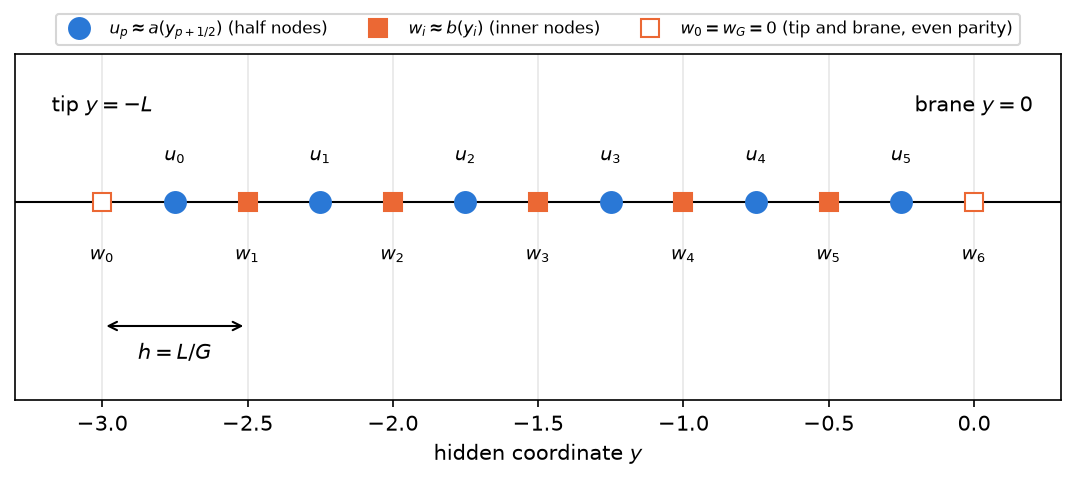

Figure 16b.1 saved as Revision/textbook/figures/16b_1_staggered_grid.png


In [3]:
G_SHOW = 6
h_show = L_VALUE / G_SHOW
nodes = -L_VALUE + h_show * np.arange(G_SHOW + 1)  # y_0, ..., y_G
halves = -L_VALUE + h_show * (np.arange(G_SHOW) + 0.5)  # y_{1/2}, ..., y_{G-1/2}
fig, ax = plt.subplots(figsize=(9.0, 3.0))
ax.axhline(0.0, color="k", lw=1.0)
ax.plot(halves, np.zeros(G_SHOW), "o", color=PALETTE[0], ms=10,
        label="$u_p \\approx a(y_{p+1/2})$ (half nodes)")
ax.plot(nodes[1:-1], np.zeros(G_SHOW - 1), "s", color=PALETTE[1], ms=9,
        label="$w_i \\approx b(y_i)$ (inner nodes)")
ax.plot(nodes[[0, -1]], [0.0, 0.0], "s", color=PALETTE[1], ms=9, mfc="white",
        label="$w_0 = w_G = 0$ (tip and brane, even parity)")
for p_index, yp in enumerate(halves):
    ax.annotate(f"$u_{p_index}$", (yp, 0.0), (yp, 0.25), ha="center", fontsize=9)
for i_index, yi in enumerate(nodes):
    ax.annotate(f"$w_{i_index}$", (yi, 0.0), (yi, -0.35), ha="center", fontsize=9)
ax.annotate("tip $y = -L$", (nodes[0], 0.0), (nodes[0], 0.55), ha="center")
ax.annotate("brane $y = 0$", (nodes[-1], 0.0), (nodes[-1], 0.55), ha="center")
ax.annotate("", (nodes[1], -0.75), (nodes[0], -0.75),
            arrowprops={"arrowstyle": "<->"})
ax.text(0.5 * (nodes[0] + nodes[1]), -0.95, "$h = L/G$", ha="center")
ax.set_ylim(-1.2, 0.9)
ax.set_xlim(-L_VALUE - 0.3, 0.3)
ax.set_yticks([])
ax.set_xlabel("hidden coordinate $y$")
ax.legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.0), ncol=3)
save_figure(fig, "staggered_grid",
            "The staggered grid of the reference solver for $G = 6$ cells of width "
            "$h = L/G = 0.5$ on the hidden coordinate $-3 \\le y \\le 0$: the first "
            "orbital component $a$ is stored at the cell centres (circles, $u_p$), "
            "the second component $b$ at the inner cell ends (squares, $w_i$); at the "
            "tip and at the brane $b$ is zero (open squares) and is not an unknown. "
            "The $2G - 1 = 11$ unknowns alternate $u_0, w_1, u_1, \\dots, u_5$.")

## 7. From the differential equation to a matrix

The equations of section 4 at $k = 0$, written as an eigenvalue problem
$\varepsilon\,(a, b) = h\,(a, b)$, are (multiply the second by $j$ and the first by
$-j$, using $j^2 = 1$)
$$\varepsilon\,a = j\,(b' + M b), \qquad \varepsilon\,b = j\,(-a' + M a).$$
**Discretise** each at the place where its left side is stored, with centred
differences (the value halfway between two neighbours, and the difference of the two
neighbours divided by their distance $h$):

- at the half node $y_{p+1/2}$ (row of $u_p$): $b' \approx (w_{p+1} - w_p)/h$ and
  $b \approx (w_p + w_{p+1})/2$, so
  $\varepsilon\,u_p = j(-\tfrac1h + \tfrac M2)\,w_p + j(\tfrac1h + \tfrac M2)\,w_{p+1}$;
- at the node $y_i$ (row of $w_i$): $a' \approx (u_i - u_{i-1})/h$ and
  $a \approx (u_{i-1} + u_i)/2$, so
  $\varepsilon\,w_i = j(\tfrac1h + \tfrac M2)\,u_{i-1} + j(-\tfrac1h + \tfrac M2)\,u_i$.

In the order $(u_0, w_1, u_1, \dots)$ every row couples only to its two neighbours,
so the matrix $T$ is **tridiagonal**: the diagonal is zero (no $\varepsilon$-free
term at $k = 0$), and the entry between neighbours number $r$ and $r + 1$ is
$j(\tfrac1h + \tfrac M2)$ when $r$ is even (a $u$ followed by a $w$) and
$j(-\tfrac1h + \tfrac M2)$ when $r$ is odd (a $w$ followed by a $u$). The coefficient
of $w_{p+1}$ in the row of $u_p$ equals the coefficient of $u_p$ in the row of
$w_{p+1}$, and likewise for $w_p$: $T$ is **symmetric**, so its eigenvalues are real,
as the levels of a self-adjoint problem must be. Centred differences and averages
have errors of order $h^2$ with only even powers of $h$, which is what Richardson
extrapolation needs.

The next cell builds the diagonal and the off-diagonal of $T$ for even parity, prints
the whole matrix for $G = 4$, and compares the arrays for $G = 4$ and $G = 300$ with
those of the reference's own function `sector_arrays` in `ks_fd.py` (for $\lambda = 0$,
$k = 0$, even parity, $j = +1$).

In [4]:
sys.dont_write_bytecode = True  # do not write a __pycache__ folder into the record
sys.path.insert(0, str(repository_file("Revision/kohn_sham/reference")))
import ks_fd as K  # noqa: E402  the reference solver's module (Revision code)


def even_matrix(G, j=1.0, M=M_VALUE, L=L_VALUE):
    """Diagonal d (2G - 1 numbers) and off-diagonal o (2G - 2 numbers) of T for
    even parity, k = 0, constant M."""
    h = L / G
    d = np.zeros(2 * G - 1)  # the diagonal is zero at k = 0
    r = np.arange(2 * G - 2)  # the number of the first of two neighbours
    o = np.where(r % 2 == 0, j * (1.0 / h + M / 2.0), j * (-1.0 / h + M / 2.0))
    return d, o


d4, o4 = even_matrix(4)
T4 = np.diag(d4) + np.diag(o4, 1) + np.diag(o4, -1)  # the full 7 x 7 matrix
print("T for G = 4 (h = 0.75), even parity, j = +1:")
for row in T4:
    print("  " + " ".join(f"{x:+7.3f}" for x in row))
for G in (4, 300):
    d, o = even_matrix(G)
    phys = K.Phys(m=M_VALUE, L=L_VALUE, H=1.0)  # the reference's parameters
    grid = K.Grid(phys, G)
    sector = K.Sectors([(0, 1, 1, 0)])  # (n2 = 0, r3 = 1, j = +1, even)
    alpha, beta = K.sector_arrays(grid, phys, sector, np.full(grid.n, M_VALUE),
                                  np.zeros(grid.n))
    check(np.array_equal(alpha[:, 0], d) and np.array_equal(beta[:, 0], o),
          f"G = {G}: our matrix equals the reference's (ks_fd.sector_arrays), "
          "entry by entry")
check(np.array_equal(T4, T4.T), "the matrix is symmetric")

T for G = 4 (h = 0.75), even parity, j = +1:
   +0.000  +1.833  +0.000  +0.000  +0.000  +0.000  +0.000
   +1.833  +0.000  -0.833  +0.000  +0.000  +0.000  +0.000
   +0.000  -0.833  +0.000  +1.833  +0.000  +0.000  +0.000
   +0.000  +0.000  +1.833  +0.000  -0.833  +0.000  +0.000
   +0.000  +0.000  +0.000  -0.833  +0.000  +1.833  +0.000
   +0.000  +0.000  +0.000  +0.000  +1.833  +0.000  -0.833
   +0.000  +0.000  +0.000  +0.000  +0.000  -0.833  +0.000
PASS G = 4: our matrix equals the reference's (ks_fd.sector_arrays), entry by entry
PASS G = 300: our matrix equals the reference's (ks_fd.sector_arrays), entry by entry
PASS the matrix is symmetric


## 8. Eigenvalues by counting: the Sturm count and bisection

How does one find eigenvalue number $i$ of a matrix with thousands of rows without
computing all of them? The reference counts. For a number $x$ form the **pivots**
$$q_1 = d_1 - x, \qquad q_r = d_r - x - \frac{o_{r-1}^2}{q_{r-1}}
\quad (r = 2, \dots, n).$$
They are the numbers that appear on the diagonal when $T - x\,\mathbb{1}$ is written
as $\mathcal{L} D \mathcal{L}^T$ ($\mathcal{L}$ with ones on the diagonal, $D$
diagonal; a script letter, because $L$ is the length 3), by elimination row after
row. **Sylvester's law of inertia** (a theorem of linear algebra that we quote, not
prove) says that $T - x\,\mathbb{1}$ and $D$ have the same number of negative
eigenvalues; the eigenvalues of $T - x\,\mathbb{1}$ are $\varepsilon - x$; so the
number of negative pivots is the number $c(x)$ of eigenvalues of $T$ below $x$. A
pivot that is exactly zero is replaced by a tiny negative number (as in `ks_fd`).

**Bisection** then finds eigenvalue number $i$ (counting from 0): start with an
interval $[lo, hi]$ with $c(lo) \le i < c(hi)$ (the **Gershgorin** bounds
$\min(d - |o_{left}| - |o_{right}|) - 1$ and $\max(d + \dots) + 1$ contain every
eigenvalue); take the midpoint; if $c(mid) \le i$ the eigenvalue is above $mid$,
otherwise below; keep the half that contains it; repeat until the interval is
shorter than $10^{-14}\max(1, |lo|)$. No eigenvalue can be missed or counted twice.

The next cell writes both as functions, works on many matrices or many $x$ at once
(numpy arrays), and compares the result for $G = 150$ with `numpy.linalg.eigvalsh`,
a standard routine that computes all eigenvalues of a symmetric matrix.

In [5]:
def sturm_count(d, o, x):
    """Number of eigenvalues below x of the tridiagonal matrix (d, o), for every
    entry of the array x."""
    x = np.asarray(x, dtype=float)
    o2 = o * o
    q = d[0] - x  # the first pivot
    q = np.where(np.abs(q) < 1e-290, -1e-290, q)  # never divide by an exact zero
    count = (q < 0).astype(int)
    for r in range(1, len(d)):
        q = d[r] - x - o2[r - 1] / q  # the next pivot
        q = np.where(np.abs(q) < 1e-290, -1e-290, q)
        count += q < 0
    return count


def bisection(d, o, index, rel_tol=1e-14):
    """Eigenvalues number index (an array of integers, 0 = the lowest) of (d, o)."""
    index = np.asarray(index)
    radius = np.zeros_like(d)
    radius[:-1] += np.abs(o)
    radius[1:] += np.abs(o)
    lo = np.full(len(index), np.min(d - radius) - 1.0)  # Gershgorin: below all
    hi = np.full(len(index), np.max(d + radius) + 1.0)  # Gershgorin: above all
    steps = 0
    while np.any(hi - lo > rel_tol * np.maximum(1.0, np.abs(lo))):
        mid = 0.5 * (lo + hi)
        above = sturm_count(d, o, mid) <= index  # True: the eigenvalue is above mid
        lo = np.where(above, mid, lo)
        hi = np.where(above, hi, mid)
        steps += 1
    return 0.5 * (lo + hi), steps


d150, o150 = even_matrix(150)
T150 = np.diag(d150) + np.diag(o150, 1) + np.diag(o150, -1)
all_eigs = np.linalg.eigvalsh(T150)  # every eigenvalue, sorted
test_x = np.linspace(-6.0, 6.0, 241) + 0.0123  # 241 test points, none at a level
counts_ok = np.array_equal(sturm_count(d150, o150, test_x),
                           np.searchsorted(all_eigs, test_x))
first_particle = int(sturm_count(d150, o150, np.array([-1e-9]))[0])
found, steps = bisection(d150, o150, first_particle + RANKS)
say(f"G = 150: {len(all_eigs)} eigenvalues; {first_particle} lie below -1e-9, so the "
    f"lowest particle level (rank 0) is eigenvalue number {first_particle}")
say(f"bisection: {steps} halvings; largest difference from eigvalsh "
    f"{np.max(np.abs(found - all_eigs[first_particle + RANKS])):.1e}")
check(counts_ok, "the Sturm count equals the number of eigvalsh eigenvalues below x "
                 "at 241 test points")
check(np.max(np.abs(found - all_eigs[first_particle + RANKS])) < 1e-12,
      "bisection with Sturm counts finds the same nine levels as eigvalsh")

G = 150: 299 eigenvalues; 149 lie below -1e-9, so the lowest particle level (rank 0) is
    eigenvalue number 149
bisection: 55 halvings; largest difference from eigvalsh 3.8e-14
PASS the Sturm count equals the number of eigvalsh eigenvalues below x at 241 test points
PASS bisection with Sturm counts finds the same nine levels as eigvalsh


The next figure shows the Sturm count as a staircase for a coarse grid ($G = 30$, 59
eigenvalues): $c(x)$ jumps by one at every eigenvalue. The exact levels of section 5
are drawn as dashed lines: the low eigenvalues of the grid sit almost exactly on
them, the high ones (whose orbitals oscillate on the scale of a few cells) are
visibly shifted.

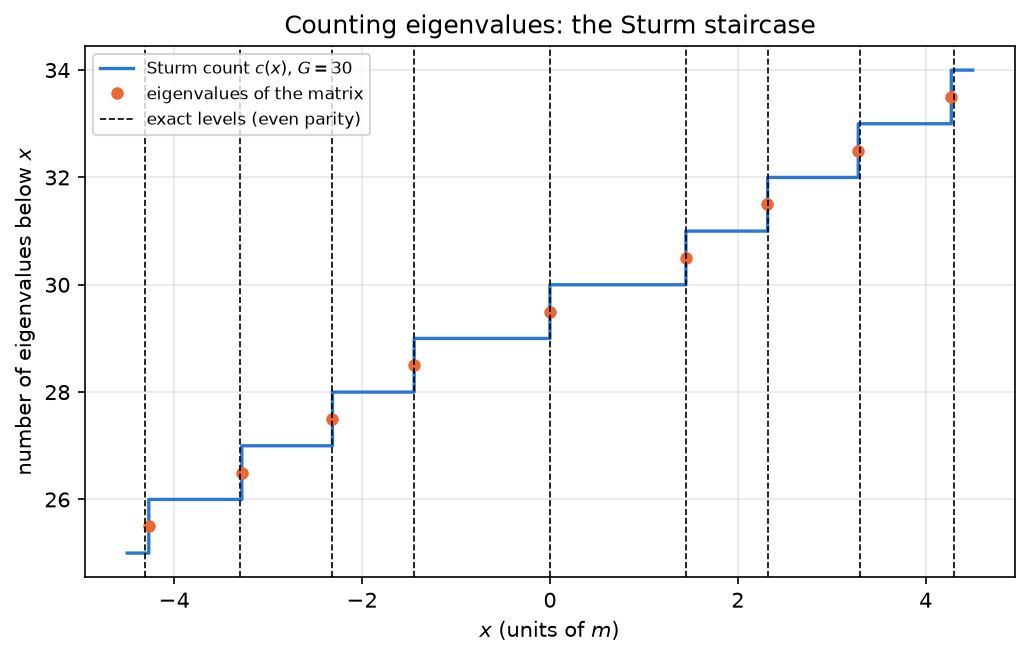

Figure 16b.2 saved as Revision/textbook/figures/16b_2_sturm_staircase.png
PASS the staircase rises by one for each eigenvalue in the window


In [6]:
d30, o30 = even_matrix(30)
xs = np.linspace(-4.5, 4.5, 3601)  # a fine set of x values
stairs = sturm_count(d30, o30, xs)
eigs30 = np.linalg.eigvalsh(np.diag(d30) + np.diag(o30, 1) + np.diag(o30, -1))
fig, ax = plt.subplots(figsize=(8.0, 4.6))
ax.step(xs, stairs, where="post", color=PALETTE[0], lw=1.6,
        label="Sturm count $c(x)$, $G = 30$")
shown = eigs30[np.abs(eigs30) < 4.5]
ax.plot(shown, np.searchsorted(eigs30, shown) + 0.5, "o", color=PALETTE[1], ms=5,
        label="eigenvalues of the matrix")
exact_lines = [0.0] + [s * math.sqrt(1.0 + (n * math.pi / 3.0) ** 2)
                       for n in range(1, 5) for s in (1, -1)]
for k, e in enumerate(sorted(exact_lines)):
    ax.axvline(e, color="k", lw=0.8, ls="--",
               label="exact levels (even parity)" if k == 0 else None)
ax.set_xlabel("$x$ (units of $m$)")
ax.set_ylabel("number of eigenvalues below $x$")
ax.set_title("Counting eigenvalues: the Sturm staircase")
ax.legend(fontsize=8, loc="upper left")
save_figure(fig, "sturm_staircase",
            "The Sturm count $c(x)$, the number of eigenvalues below $x$ of the "
            "even-parity matrix with $G = 30$ cells ($M = 1$, $L = 3$, $k = 0$), "
            "against $x$ in units of $m$. The count rises by one at each eigenvalue "
            "(circles, from a standard eigenvalue routine); the dashed lines are the "
            "exact levels $0$ and $\\pm\\sqrt{1 + (n\\pi/3)^2}$. Bisection finds "
            "eigenvalue number $i$ by asking only how many eigenvalues lie below a "
            "trial value.")
check(int(sturm_count(d30, o30, np.array([4.5]))[0]
          - sturm_count(d30, o30, np.array([-4.5]))[0]) == len(shown),
      "the staircase rises by one for each eigenvalue in the window")

## 9. The exact discrete zero mode, and the orbitals

At $k = 0$ the grid problem has an eigenvalue that is **exactly** zero. Put
$\varepsilon = 0$ and $w_i = 0$ for every $i$: the rows of the $u$ are then
satisfied, and the row of $w_i$ demands
$(\tfrac1h + \tfrac M2)\,u_{i-1} + (-\tfrac1h + \tfrac M2)\,u_i = 0$, that is
$$u_i = q\,u_{i-1}, \qquad q = \frac{1 + Mh/2}{1 - Mh/2}.$$
So $u_p = q^p\,u_0$: a discrete exponential. Because
$\ln q = \ln(1 + Mh/2) - \ln(1 - Mh/2) = Mh + (Mh)^3/12 + \dots$, it follows the exact
zero mode $e^{My}$ up to an error of order $h^2$, and $b = 0$ exactly, as in the
continuum. A practical point: computing $q$ first and then $q^p$ multiplies the
rounding error of $q$ (about $10^{-16}$) by $p$, up to $10^{-13}$ for $p = 1200$;
computing $u_p = e^{p \ln q}$ with $\ln q$ from the two logarithms
(`numpy.log1p(x)` $= \ln(1 + x)$, accurate also for small $x$) avoids that.

The next cell builds the discrete zero mode for $G = 150$, checks $T z = 0$ to
rounding, and also takes from `numpy.linalg.eigh` (eigenvalues and eigenvectors) the
orbital of the even level of rank 1, $\varepsilon = \sqrt{1 + (\pi/3)^2}$. An
eigenvector $z$ of length 1 holds $u_p\sqrt h$ and $w_i\sqrt h$, so that
$\sum (u^2 + w^2)\,h = 1$ approximates $\int (a^2 + b^2)\,dy = 1$.

In [7]:
def zero_mode(G, M=M_VALUE, L=L_VALUE):
    """The exact discrete zero mode: u_p = exp(p ln q), normalised so that
    sum u^2 h = 1; returns (half nodes y, u)."""
    h = L / G
    log_q = np.log1p(M * h / 2.0) - np.log1p(-M * h / 2.0)  # ln q, accurately
    u = np.exp(np.arange(G) * log_q)
    u /= math.sqrt(np.sum(u * u) * h)
    return -L + (np.arange(G) + 0.5) * h, u


y_half, u0 = zero_mode(150)
z = np.zeros(2 * 150 - 1)
z[0::2] = u0  # the u entries; every w entry stays 0
residual = np.max(np.abs(T150 @ z)) / np.max(np.abs(z))
A = math.sqrt(2.0 * M_VALUE / (1.0 - math.exp(-2.0 * M_VALUE * L_VALUE)))
shape_error = np.max(np.abs(u0 - A * np.exp(M_VALUE * y_half)))
say(f"discrete zero mode, G = 150: |T z| / |z| = {residual:.1e}; largest distance "
    f"from A e^(My) at the half nodes {shape_error:.2e} (A = {A:.6f})")
check(residual < 1e-12, "the discrete zero mode is an exact eigenvector with "
                        "eigenvalue 0 (to rounding), with b = 0")
check(shape_error < 1e-3, "the discrete zero mode follows A e^(My) to order h^2")

values, vectors = np.linalg.eigh(T150)
level = first_particle + 1  # rank 1
vec = vectors[:, level] / math.sqrt(L_VALUE / 150)  # u and w with sum (u^2+w^2) h = 1
vec *= np.sign(vec[-1])  # fix the overall sign: u at the brane positive
u1, w1 = vec[0::2], vec[1::2]
y_node = -L_VALUE + np.arange(1, 150) * (L_VALUE / 150)
p1 = math.pi / L_VALUE
e1 = math.sqrt(M_VALUE ** 2 + p1 ** 2)
b_exact = lambda yy: np.sin(p1 * (yy + L_VALUE))
a_exact = lambda yy: (p1 * np.cos(p1 * (yy + L_VALUE))
                      + M_VALUE * np.sin(p1 * (yy + L_VALUE))) / e1
norm_exact = math.sqrt(L_VALUE)  # int (a^2 + b^2) dy = L for these a and b
scale = np.sign(a_exact(np.array([y_half[-1]]))[0]) / norm_exact
say(f"level of rank 1: eigenvalue {values[level]:.10f}, exact {e1:.10f}")
check(np.max(np.abs(u1 - scale * a_exact(y_half))) < 1e-3
      and np.max(np.abs(w1 - scale * b_exact(y_node))) < 1e-3,
      "the eigenvector of rank 1 follows the exact orbital (a, b) to order h^2")

discrete zero mode, G = 150: |T z| / |z| = 1.5e-14; largest distance from A e^(My) at the
    half nodes 6.93e-05 (A = 1.415970)
PASS the discrete zero mode is an exact eigenvector with eigenvalue 0 (to rounding), with
    b = 0
PASS the discrete zero mode follows A e^(My) to order h^2
level of rank 1: eigenvalue 1.4479202214, exact 1.4479719304
PASS the eigenvector of rank 1 follows the exact orbital (a, b) to order h^2


The next figure draws both orbitals: left the zero mode $a(y)$ (with $b = 0$), right
the two components of the level of rank 1; the grid values are drawn at every fifth
point, the exact functions as lines.

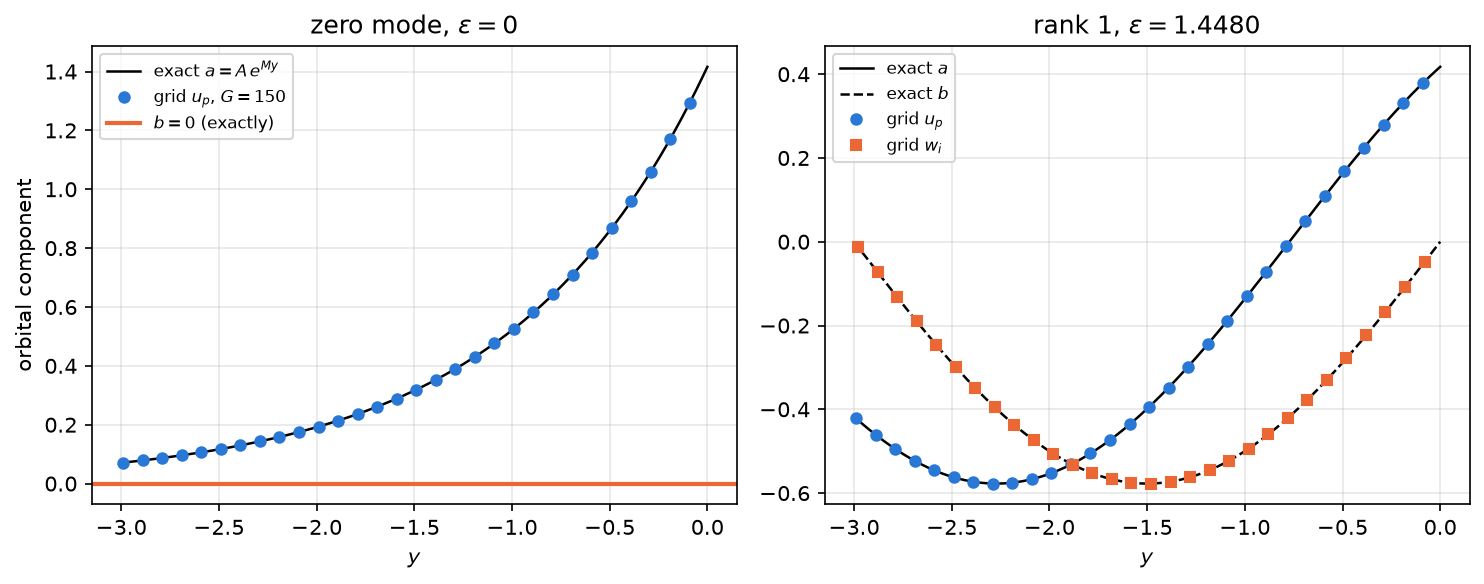

Figure 16b.3 saved as Revision/textbook/figures/16b_3_orbitals.png


In [8]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0))
fine = np.linspace(-L_VALUE, 0.0, 400)
left.plot(fine, A * np.exp(M_VALUE * fine), color="k", lw=1.2,
          label="exact $a = A\\,e^{My}$")
left.plot(y_half[::5], u0[::5], "o", color=PALETTE[0], ms=5,
          label="grid $u_p$, $G = 150$")
left.axhline(0.0, color=PALETTE[1], lw=2.0, label="$b = 0$ (exactly)")
left.set_xlabel("$y$")
left.set_ylabel("orbital component")
left.set_title("zero mode, $\\varepsilon = 0$")
left.legend(fontsize=8)
right.plot(fine, scale * a_exact(fine), color="k", lw=1.2, label="exact $a$")
right.plot(fine, scale * b_exact(fine), color="k", lw=1.2, ls="--",
           label="exact $b$")
right.plot(y_half[::5], u1[::5], "o", color=PALETTE[0], ms=5, label="grid $u_p$")
right.plot(y_node[::5], w1[::5], "s", color=PALETTE[1], ms=5, label="grid $w_i$")
right.set_xlabel("$y$")
right.set_title(f"rank 1, $\\varepsilon = {e1:.4f}$")
right.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "orbitals",
            "Orbitals of the free problem at zero 3-momentum ($M = 1$, $L = 3$), "
            "normalised to $\\int (a^2 + b^2)\\,dy = 1$, against the hidden coordinate "
            "$y$ (tip $-3$, brane $0$). Left: the zero mode, $a = A e^{My}$ with "
            "$A = \\sqrt{2M/(1 - e^{-2ML})}$ and $b = 0$, localised at the brane; the "
            "circles are the exact discrete zero mode $u_p = q^p u_0$ of the grid "
            "with $G = 150$. Right: the even level of rank 1, "
            "$\\varepsilon = \\sqrt{1 + (\\pi/3)^2}$: its $b$ vanishes at the tip "
            "and at the brane, and the grid values lie on the exact curves.")

## 10. Odd parity: the rotated frame

For odd parity the brane condition is $a(0) = 0$, but $a$ is stored at half nodes, so
no unknown sits at $y = 0$ to be set to zero. The reference therefore rotates the
two components before discretising. With the Pauli matrices
$\sigma_1, \sigma_2, \sigma_3$ and an angle $\phi(y)$ write
$\chi = e^{i\phi\sigma_1}\psi$, $\psi = (u, i\,w)$. Then:

- $e^{i\phi\sigma_1} = \cos\phi + i\sin\phi\,\sigma_1$ (because $\sigma_1^2 = 1$), so
  $a = \cos\phi\,u - \sin\phi\,w$ and $b = \sin\phi\,u + \cos\phi\,w$.
- Choose $\phi = j\,\frac{\pi}{2}\,\frac{y + L}{L}$: at the tip $\phi = 0$, so
  $b = w$ and $b(-L) = 0$ means $w(-L) = 0$; at the brane $\phi = j\pi/2$, so
  $a = -j\,w$ and $a(0) = 0$ means $w(0) = 0$. Both conditions are again "$w = 0$ at
  the ends", and the same staggered grid works.
- The equation for $\psi$ has the same form, $h' = j[-i\sigma_1\,d/dy + \phi' +
  m_2\sigma_2 + k_2\sigma_3] + v$, with $m_2 = M\cos 2\phi - K\sin 2\phi$ and
  $k_2 = M\sin 2\phi + K\cos 2\phi$ ($K = \kappa k$): the derivative of
  $e^{i\phi\sigma_1}$ gives the extra number $\phi'$, and the rotation turns
  $\sigma_2$ into $\cos 2\phi\,\sigma_2 + \sin 2\phi\,\sigma_3$ and $\sigma_3$ into
  $\cos 2\phi\,\sigma_3 - \sin 2\phi\,\sigma_2$. The next cell checks these two
  identities with sympy.
- In the matrix, $\phi' + k_2$ goes on the diagonal of the $u$ rows,
  $\phi' - k_2$ on the diagonal of the $w$ rows ($\sigma_3 = $ diag$(1, -1)$), both
  times $j$, and $M$ in the off-diagonal entries is replaced by $m_2$ (taken at the
  half node of the pair). For even parity $\phi = 0$ and everything reduces to
  section 7, with $\pm j K$ on the diagonal when $k \ne 0$.

The cell then writes the general function `sector_matrix` (both parities, any $k$
and slice $a_{4,0}$) and checks it against `ks_fd.sector_arrays` for both parities,
both block types, and $k = 0$ and $k = 0.5$.

In [9]:
phi = sp.symbols("phi", real=True)
s1 = sp.Matrix([[0, 1], [1, 0]])  # the Pauli matrices
s2 = sp.Matrix([[0, -sp.I], [sp.I, 0]])
s3 = sp.Matrix([[1, 0], [0, -1]])
rot = sp.cos(phi) * sp.eye(2) + sp.I * sp.sin(phi) * s1  # e^{i phi sigma1}
back = sp.cos(phi) * sp.eye(2) - sp.I * sp.sin(phi) * s1  # e^{-i phi sigma1}
ok2 = sp.simplify(back * s2 * rot - (sp.cos(2 * phi) * s2 + sp.sin(2 * phi) * s3))
ok3 = sp.simplify(back * s3 * rot - (sp.cos(2 * phi) * s3 - sp.sin(2 * phi) * s2))
check(ok2 == sp.zeros(2, 2) and ok3 == sp.zeros(2, 2),
      "sympy: the rotation turns sigma2 into cos(2 phi) sigma2 + sin(2 phi) sigma3 "
      "and sigma3 into cos(2 phi) sigma3 - sin(2 phi) sigma2")


def sector_matrix(G, odd, j=1.0, k=0.0, a4=0.0, M=M_VALUE, L=L_VALUE, H=1.0):
    """Diagonal and off-diagonal of T for one sector: parity (odd True/False),
    block type j, 3-momentum k, slice a4; constant M, v = 0."""
    h = L / G
    r = np.arange(2 * G - 1)  # the position of each unknown in the list
    y_r = -L + (r + 1) * h / 2.0  # its y (half node for even r, node for odd r)
    is_u = r % 2 == 0
    K_r = np.exp(-H * y_r - a4) * k  # K = kappa k
    angle = j * 0.5 * math.pi * (y_r + L) / L if odd else np.zeros_like(y_r)
    dangle = j * math.pi / (2.0 * L) if odd else 0.0  # phi'
    m2 = M * np.cos(2 * angle) - K_r * np.sin(2 * angle)
    k2 = M * np.sin(2 * angle) + K_r * np.cos(2 * angle)
    d = np.where(is_u, j * (dangle + k2), j * (dangle - k2))
    pair = np.arange(2 * G - 2)  # the pair (r, r + 1)
    u_of_pair = np.where(pair % 2 == 0, pair, pair + 1)  # its half node
    sign = np.where(pair % 2 == 0, 1.0, -1.0)  # +1/h (u then w), -1/h (w then u)
    o = j * (sign / h + 0.5 * m2[u_of_pair])
    return d, o


agree = []
for odd in (False, True):
    for j_value in (1.0, -1.0):
        for n2, r3, k_value in ((0, 1, 0.0), (4, 6, 0.5)):  # |k| = 0.25 sqrt(n2)
            phys = K.Phys(m=M_VALUE, L=L_VALUE, H=1.0)
            grid = K.Grid(phys, 300)
            sector = K.Sectors([(n2, r3, j_value, int(odd))])
            alpha, beta = K.sector_arrays(grid, phys, sector,
                                          np.full(grid.n, M_VALUE), np.zeros(grid.n))
            d, o = sector_matrix(300, odd, j=j_value, k=k_value)
            agree.append(max(np.max(np.abs(alpha[:, 0] - d)),
                             np.max(np.abs(beta[:, 0] - o))))
say(f"largest difference from ks_fd.sector_arrays over 8 sectors: {max(agree):.1e}")
check(max(agree) <= 1e-12,
      "sector_matrix equals the reference's matrices for both parities, both block "
      "types, k = 0 and k = 0.5")

PASS sympy: the rotation turns sigma2 into cos(2 phi) sigma2 + sin(2 phi) sigma3 and
    sigma3 into cos(2 phi) sigma3 - sin(2 phi) sigma2
largest difference from ks_fd.sector_arrays over 8 sectors: 0.0e+00
PASS sector_matrix equals the reference's matrices for both parities, both block types, k
    = 0 and k = 0.5


The next figure shows the two matrices for $G = 8$ (15 unknowns, $j = +1$, $k = 0$)
as heat maps: the colour of square $(r, c)$ is the entry $T_{rc}$. Both are
tridiagonal and symmetric. In the even matrix the diagonal is zero and the
off-diagonal entries alternate between $1/h + M/2$ and $-1/h + M/2$; in the odd
matrix the rotation adds $\phi' \pm M\sin 2\phi$ on the diagonal.

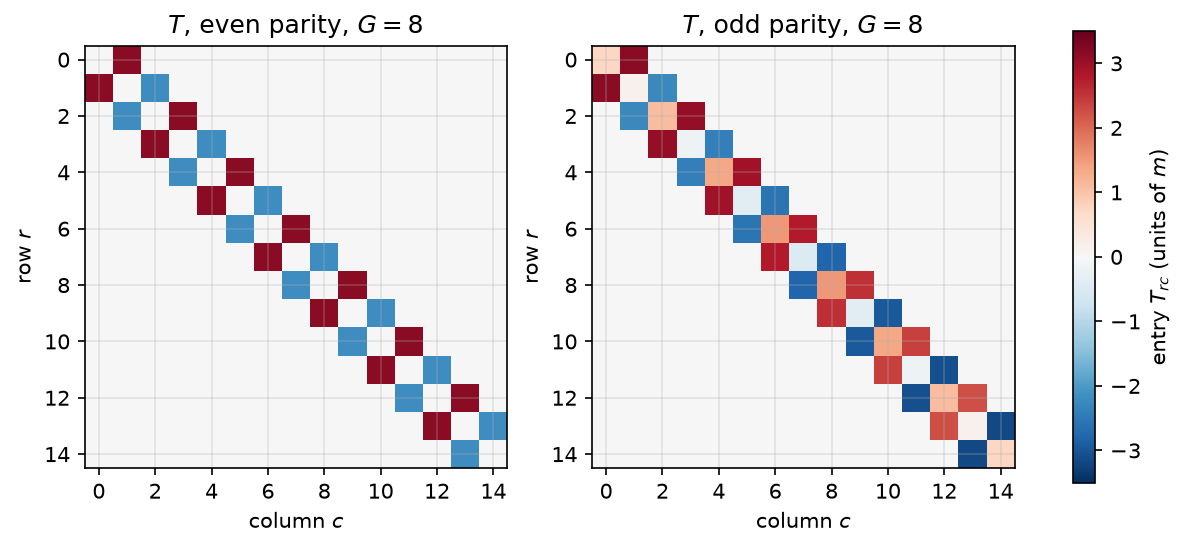

Figure 16b.4 saved as Revision/textbook/figures/16b_4_matrix_heat_maps.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.6))
for ax, odd, title in ((axes[0], False, "even parity"), (axes[1], True, "odd parity")):
    d, o = sector_matrix(8, odd)
    T = np.diag(d) + np.diag(o, 1) + np.diag(o, -1)
    image = ax.imshow(T, cmap="RdBu_r", vmin=-3.5, vmax=3.5)
    ax.set_title(f"$T$, {title}, $G = 8$")
    ax.set_xticks(range(0, 15, 2))  # whole numbers: rows and columns 0 to 14
    ax.set_yticks(range(0, 15, 2))
    ax.set_xlabel("column $c$")
    ax.set_ylabel("row $r$")
fig.colorbar(image, ax=axes, shrink=0.85, label="entry $T_{rc}$ (units of $m$)")
save_figure(fig, "matrix_heat_maps",
            "The reference matrices $T$ for $G = 8$ cells ($h = 0.375$, $M = 1$, "
            "$L = 3$, $j = +1$, $k = 0$) as heat maps, entry $T_{rc}$ in units of $m$ "
            "by colour (blue negative, red positive, white zero). Left, even parity: "
            "only the two neighbouring diagonals are filled, alternating "
            "$1/h + M/2 = 3.17$ and $-1/h + M/2 = -2.17$. Right, odd parity in the "
            "rotated frame: the diagonal carries $\\phi' \\pm M\\sin 2\\phi$ and the "
            "off-diagonal entries are $\\pm 1/h + \\tfrac12 M\\cos 2\\phi$, with "
            "$\\phi$ at the half node of the pair; $M\\cos 2\\phi$ goes from $+M$ at "
            "the tip to $-M$ at the brane, so the red entries fall from 3.16 to "
            "2.25 and the blue ones from -2.25 to -3.16, without a change of sign.")

## 11. Five grids: second order, and Richardson removes the error

The next cell finds the levels of ranks $-3$ to $5$ of both parities ($j = +1$) on
$G = 150, 300, 600, 1200, 2400$ by Sturm counts and bisection, and their distances
from the exact levels. It then forms, from $G = 300, 600, 1200$, the Richardson value
$R$ and its uncertainty $U$ exactly as the reference does, and compares them, level
by level, with the record `free-checks.json` (rows with $M = 1$, $L = 3$, $j = +1$).
This cell takes about ten seconds; the largest matrix has 4799 rows.

In [11]:
GRIDS = (150, 300, 600, 1200, 2400)
EXACT = np.concatenate([EXACT_EVEN, EXACT_ODD])  # 18 levels: even, then odd
LEVELS = {}  # G -> the 18 levels on that grid
for G in GRIDS:
    found = []
    for odd in (False, True):
        d, o = sector_matrix(G, odd)
        lowest_particle = int(sturm_count(d, o, np.array([-1e-9]))[0])
        values_g, _ = bisection(d, o, lowest_particle + RANKS)
        found.append(values_g)
    LEVELS[G] = np.concatenate(found)
    say(f"G = {G:4d}: largest |level - exact| = "
        f"{np.max(np.abs(LEVELS[G] - EXACT)):.3e}")


def richardson(x1, x2, x3):
    """Three-grid Richardson value and uncertainty, as in the reference program."""
    r_fine, r_coarse = (4.0 * x3 - x2) / 3.0, (4.0 * x2 - x1) / 3.0
    R = (16.0 * r_fine - r_coarse) / 15.0
    return R, np.abs(R - r_fine) + 2e-12 * np.maximum(1.0, np.abs(R))


R18, U18 = richardson(LEVELS[300], LEVELS[600], LEVELS[1200])
record = json.loads(repository_file(
    "Revision/kohn_sham/reference/results/free-checks.json").read_text(encoding="utf-8"))
rows = [r for r in record["analytic"]["rows"]
        if float(r[0]) == 1.0 and float(r[1]) == 3.0 and r[3] == 1]
order = [(par, rank) for par in ("even", "odd") for rank in RANKS]
check([(r[2], r[4]) for r in rows] == order, "the record has our 18 rows in our order")
dev_R = max(abs(float(r[5]) - R18[i]) for i, r in enumerate(rows))
dev_U = max(abs(float(r[6]) - U18[i]) for i, r in enumerate(rows))
dev_1200 = max(abs(float(r[9]) - (LEVELS[1200][i] - EXACT[i]))
               for i, r in enumerate(rows))
say(f"against the record: R differs by at most {dev_R:.1e}, U by {dev_U:.1e}, "
    f"G = 1200 minus exact by {dev_1200:.1e}")
say(f"Richardson value minus exact: at most {np.max(np.abs(R18 - EXACT)):.1e} "
    f"(single grid G = 1200: {np.max(np.abs(LEVELS[1200] - EXACT)):.1e})")
check(dev_R < 1e-12 and dev_U < 1e-12 and dev_1200 < 1e-12,
      "our levels, R and U reproduce the 18 rows of the record",
      record="Revision/kohn_sham/reference/results/free-checks.json, analytic rows")
check(np.max(np.abs(R18 - EXACT)) <= 1e-11,
      "the Richardson values equal the exact levels to 1e-11",
      record="Revision/kohn_sham/reports/ks-reference.json, check "
             "free_k0_analytic_spectra")

G =  150: largest |level - exact| = 2.607e-03
G =  300: largest |level - exact| = 6.518e-04
G =  600: largest |level - exact| = 1.629e-04
G = 1200: largest |level - exact| = 4.074e-05
G = 2400: largest |level - exact| = 1.018e-05
PASS the record has our 18 rows in our order
against the record: R differs by at most 8.9e-15, U by 1.3e-15, G = 1200 minus exact by
    6.2e-15
Richardson value minus exact: at most 1.2e-14 (single grid G = 1200: 4.1e-05)
PASS our levels, R and U reproduce the 18 rows of the record
     reproduces Revision/kohn_sham/reference/results/free-checks.json, analytic rows
PASS the Richardson values equal the exact levels to 1e-11
     reproduces Revision/kohn_sham/reports/ks-reference.json, check
    free_k0_analytic_spectra


The next figure is the **Richardson ladder** for three levels: the even level of
rank 1, the odd level of rank 0 and the even level of rank 5 (the highest, whose
orbital oscillates fastest). For each, against the cell width $h$: the error of the
single grids (slope 2), of one Richardson step from two neighbouring grids (slope 4),
and of the three-grid value (two steps), which reaches the rounding floor of about
$10^{-14}$ on the coarsest triple for the two lower levels and from the second
triple on for the level of rank 5.

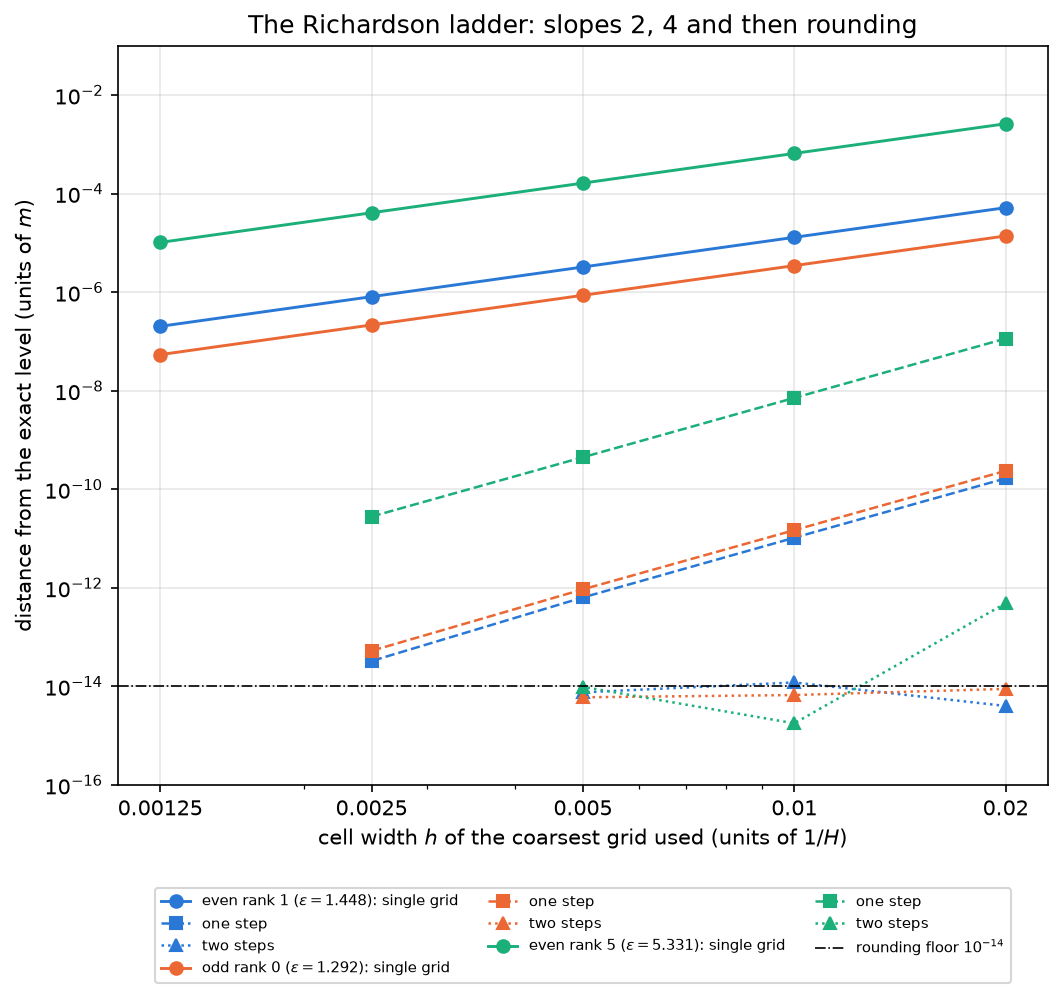

Figure 16b.5 saved as Revision/textbook/figures/16b_5_convergence_ladder.png


In [12]:
hs = np.array([L_VALUE / G for G in GRIDS])
picks = [("even", 1), ("odd", 0), ("even", 5)]
fig, ax = plt.subplots(figsize=(8.0, 6.4))
for colour, (par, rank) in zip(PALETTE, picks):
    i = order.index((par, rank))
    single = np.array([abs(LEVELS[G][i] - EXACT[i]) for G in GRIDS])
    one = np.array([abs((4.0 * LEVELS[GRIDS[g + 1]][i] - LEVELS[GRIDS[g]][i]) / 3.0
                        - EXACT[i]) for g in range(4)])
    two = np.array([abs(richardson(LEVELS[GRIDS[g]][i], LEVELS[GRIDS[g + 1]][i],
                                   LEVELS[GRIDS[g + 2]][i])[0] - EXACT[i])
                    for g in range(3)])
    label = f"{par} rank {rank} ($\\varepsilon = {EXACT[i]:.3f}$)"
    ax.loglog(hs, single, "o-", color=colour, lw=1.4, label=f"{label}: single grid")
    ax.loglog(hs[:4], one, "s--", color=colour, lw=1.2, label="one step")
    ax.loglog(hs[:3], np.maximum(two, 1e-16), "^:", color=colour, lw=1.2,
              label="two steps")
ax.axhline(1e-14, color="k", lw=0.8, ls="-.", label="rounding floor $10^{-14}$")
ax.set_xlabel("cell width $h$ of the coarsest grid used (units of $1/H$)")
ax.set_ylabel("distance from the exact level (units of $m$)")
ax.set_title("The Richardson ladder: slopes 2, 4 and then rounding")
ax.set_ylim(1e-16, 1e-1)
ax.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
ax.set_xticks(hs)  # tick labels only at the five cell widths
ax.set_xticklabels([f"{t:g}" for t in hs])
ax.legend(fontsize=7, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.13))
save_figure(fig, "convergence_ladder",
            "Distance of the computed level from the exact level, in units of $m$, "
            "against the cell width $h = 3/G$ for $G = 150$ to $2400$, logarithmic "
            "axes, for three levels of the free problem: circles, single grids "
            "(slope 2, error proportional to $h^2$); squares, one Richardson step "
            "$(4x(h/2) - x(h))/3$ (slope 4); triangles, the three-grid value of the "
            "reference (two steps), at the rounding floor near $10^{-14}$ on the "
            "coarsest triple for the two lower levels and from the second triple on "
            "for rank 5. "
            "The high level of rank 5 has the largest errors, because its orbital "
            "varies fastest from cell to cell.")

The next cell computes the **convergence ratio**
$(x(G) - x(2G))/(x(2G) - x(4G))$ for every one of the 18 levels and three triples of
grids, and draws it against the level energy. Second order means a ratio of 4; the
reference's check `free_convergence_order_two` requires every ratio of the triple
$(300, 600, 1200)$ (for all three choices of $M$ and $L$) to lie in $[3.99, 4.01]$.

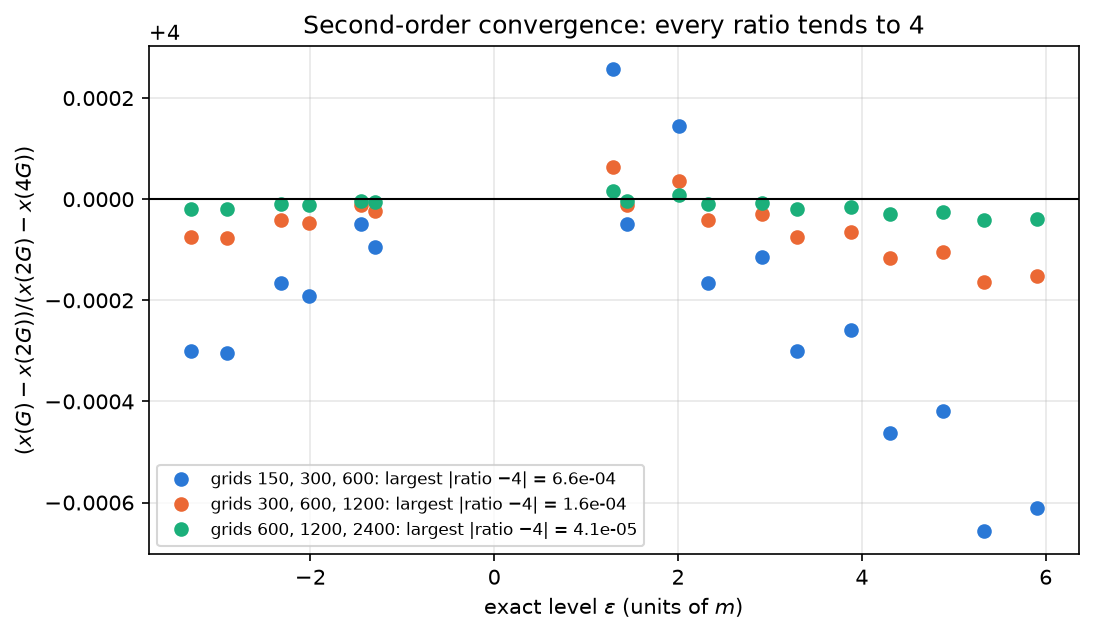

Figure 16b.6 saved as Revision/textbook/figures/16b_6_error_ratios.png
largest |ratio - 4| per triple: (150, 300, 600): 6.57e-04, (300, 600, 1200): 1.64e-04,
    (600, 1200, 2400): 4.10e-05
PASS the ratios lie within 0.01 of 4 and approach 4 on finer grids
     reproduces Revision/kohn_sham/reports/ks-reference.json, check
    free_convergence_order_two


In [13]:
fig, ax = plt.subplots(figsize=(8.0, 4.4))
worst = {}
for colour, (g1, g2, g3) in zip(PALETTE, ((150, 300, 600), (300, 600, 1200),
                                          (600, 1200, 2400))):
    d1, d2 = LEVELS[g1] - LEVELS[g2], LEVELS[g2] - LEVELS[g3]
    keep = (np.abs(d1) > 1e-10) & (np.abs(d2) > 1e-10)  # not the zero mode
    ratio = d1[keep] / d2[keep]
    worst[(g1, g2, g3)] = float(np.max(np.abs(ratio - 4.0)))
    ax.plot(EXACT[keep], ratio, "o", color=colour, ms=6,
            label=f"grids {g1}, {g2}, {g3}: largest $|$ratio $- 4|$ = "
                  f"{worst[(g1, g2, g3)]:.1e}")
ax.axhline(4.0, color="k", lw=1.0)
ax.set_xlabel("exact level $\\varepsilon$ (units of $m$)")
ax.set_ylabel("$(x(G) - x(2G))/(x(2G) - x(4G))$")
ax.set_title("Second-order convergence: every ratio tends to 4")
ax.legend(fontsize=8)
save_figure(fig, "error_ratios",
            "The convergence ratio $(x(G) - x(2G))/(x(2G) - x(4G))$ of the 17 nonzero "
            "levels of ranks $-3$ to $5$ (both parities, $M = 1$, $L = 3$, $k = 0$) "
            "against the exact level in units of $m$, for three triples of grids. A "
            "ratio of 4 means an error proportional to $h^2$; the ratios approach 4 "
            "as the grids get finer, fastest for the low levels. The zero mode (even "
            "parity, rank 0) is exact on every grid and has no ratio.")
say("largest |ratio - 4| per triple: " + ", ".join(
    f"{k}: {v:.2e}" for k, v in worst.items()))
check(worst[(300, 600, 1200)] <= 0.01
      and worst[(600, 1200, 2400)] < worst[(300, 600, 1200)]
      and int(np.sum(keep)) == 17,  # 18 levels minus the one zero mode
      "the ratios lie within 0.01 of 4 and approach 4 on finer grids",
      record="Revision/kohn_sham/reports/ks-reference.json, check "
             "free_convergence_order_two")

## 12. The brane band along the deflating history

Now switch on a small 3-momentum $k$. The zero mode is no longer exactly at zero: it
becomes the bottom of the **brane band**, $\varepsilon \approx c\,k$ for small $k$.
How large is the slope $c = d\varepsilon/dk$ at $k = 0$?

- **Hellmann-Feynman on the matrix.** If $T(k) z = \varepsilon(k) z$ with
  $z^T z = 1$, differentiating gives $d\varepsilon/dk = z^T (dT/dk) z$ (the terms
  with $dz/dk$ cancel because $T$ is symmetric and $z^T z = 1$). For even parity
  and $j = +1$, $dT/dk$ is diagonal: $+\kappa(y)$ in the $u$ rows and $-\kappa(y)$ in
  the $w$ rows (from $\pm j K$, $K = \kappa k$). The zero mode has $w = 0$, so
  $c = \sum_p \kappa(y_{p+1/2})\,u_p^2\,h$.
- **In the continuum** this is $c = \int_{-L}^{0} \kappa\,a^2\,dy$ with
  $a = A e^{My}$ and $\kappa = e^{-Hy - a_{4,0}}$:
  $c = e^{-a_{4,0}} A^2 \int_{-L}^{0} e^{(2M - H)y}\,dy
  = e^{-a_{4,0}}\,\frac{2M}{1 - e^{-2ML}}\,\frac{1 - e^{-(2M - H)L}}{2M - H}$,
  the formula `checksNumeric.braneBandSlopeFormula` of `ks-theory.json`.
- **The meaning.** The factor $e^{-a_{4,0}}$ is the redshift of the 3-momentum: along
  the history $a_4 = A H x_4$, 3-space inflates by $e^{a_4}$ while the three extra
  times deflate by $e^{-a_4}$ (the 7-volume stays constant), and the brane band
  flattens as $e^{-a_{4,0}}$.

The next cell computes $c$ on $G = 300, 600, 1200$ with the discrete zero mode of
section 9, extrapolates with Richardson, and compares with the formula and with the
record (entry `brane_band_slope` of `free-checks.json`) at the five slices
$a_{4,0} = 0, 0.5, 1, 1.5, 2$.

In [14]:
SLICES = (0.0, 0.5, 1.0, 1.5, 2.0)


def slope_formula(a4, M=M_VALUE, H=1.0, L=L_VALUE):
    """c = e^(-a4) (2M/(1 - e^(-2ML))) (1 - e^(-(2M - H)L))/(2M - H)."""
    return (math.exp(-a4) * 2.0 * M / (1.0 - math.exp(-2.0 * M * L))
            * (1.0 - math.exp(-(2.0 * M - H) * L)) / (2.0 * M - H))


per_grid = {}
for G in (300, 600, 1200):
    yh, u = zero_mode(G)
    weight = u * u * (L_VALUE / G)  # u_p^2 h, summing to 1
    per_grid[G] = np.array([np.sum(np.exp(-yh - a4) * weight) for a4 in SLICES])
R_slope, U_slope = richardson(per_grid[300], per_grid[600], per_grid[1200])
formula = np.array([slope_formula(a4) for a4 in SLICES])
theory = json.loads(repository_file("Revision/kohn_sham/ks-theory.json").read_text(
    encoding="utf-8"))
stated = float(theory["checksNumeric"]["braneBandSlope_M1_H1_L3_a0"])
rec_rows = record["brane_band_slope"]["rows"]
print("a4,0   slope (grid, Richardson)   formula            record")
for i, a4 in enumerate(SLICES):
    print(f"{a4:4.1f}   {R_slope[i]:.15f}      {formula[i]:.15f}  "
          f"{float(rec_rows[i][1]):.15f}")
rel_formula = np.max(np.abs(R_slope - formula) / formula)
rel_record = max(abs(float(r[1]) - R_slope[i]) / formula[i]
                 for i, r in enumerate(rec_rows))
say(f"largest relative difference: from the formula {rel_formula:.1e}, from the "
    f"record {rel_record:.1e}")
print("stated in ks-theory.json (checksNumeric): c at a4,0 = 0 is "
      + theory["checksNumeric"]["braneBandSlope_M1_H1_L3_a0"])
check(rel_formula <= 1e-11 and abs(slope_formula(0.0) - stated) <= 1e-15 * stated,
      "the grid slope equals c e^(-a4,0) of ks-theory.json at the five slices",
      record="Revision/kohn_sham/reports/ks-reference.json, check "
             "free_brane_band_slope")
check(rel_record <= 1e-13, "our slopes reproduce the record's brane_band_slope rows",
      record="Revision/kohn_sham/reference/results/free-checks.json, brane_band_slope")
check(np.allclose(R_slope[1:] / R_slope[:-1], math.exp(-0.5), rtol=1e-12, atol=0),
      "from slice to slice the slope shrinks by exactly e^(-0.5)")

a4,0   slope (grid, Richardson)   formula            record
 0.0   1.905148253644867      1.905148253644867  1.905148253644862
 0.5   1.155530827133593      1.155530827133592  1.155530827133590
 1.0   0.700864874899623      0.700864874899623  0.700864874899621
 1.5   0.425096034942281      0.425096034942280  0.425096034942279
 2.0   0.257833778514766      0.257833778514766  0.257833778514766
largest relative difference: from the formula 3.8e-16, from the record 2.6e-15
stated in ks-theory.json (checksNumeric): c at a4,0 = 0 is 1.9051482536448664
PASS the grid slope equals c e^(-a4,0) of ks-theory.json at the five slices
     reproduces Revision/kohn_sham/reports/ks-reference.json, check free_brane_band_slope
PASS our slopes reproduce the record's brane_band_slope rows
     reproduces Revision/kohn_sham/reference/results/free-checks.json, brane_band_slope
PASS from slice to slice the slope shrinks by exactly e^(-0.5)


The next figure draws the slope against the slice: the grid values (after
Richardson) on the exact formula, on a logarithmic vertical axis, where
$e^{-a_{4,0}}$ is a straight line. A second panel shows, for $a_{4,0} = 0$, the
single-grid values approaching the exact slope like $h^2$.

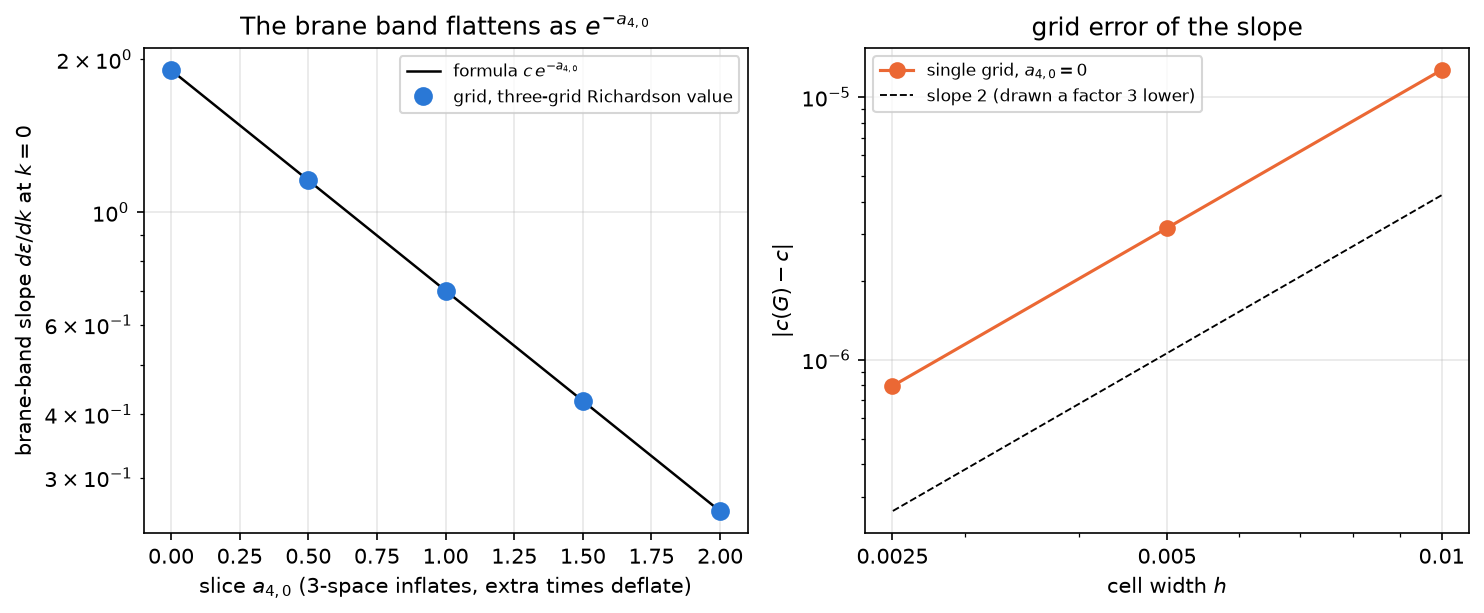

Figure 16b.7 saved as Revision/textbook/figures/16b_7_brane_band_slope.png


In [15]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.2))
a_fine = np.linspace(0.0, 2.0, 100)
left.semilogy(a_fine, [slope_formula(a) for a in a_fine], color="k", lw=1.2,
              label="formula $c\\,e^{-a_{4,0}}$")
left.semilogy(SLICES, R_slope, "o", color=PALETTE[0], ms=8,
              label="grid, three-grid Richardson value")
left.set_xlabel("slice $a_{4,0}$ (3-space inflates, extra times deflate)")
left.set_ylabel("brane-band slope $d\\varepsilon/dk$ at $k = 0$")
left.set_title("The brane band flattens as $e^{-a_{4,0}}$")
left.legend(fontsize=8)
hs3 = np.array([L_VALUE / G for G in (300, 600, 1200)])
right.loglog(hs3, [abs(per_grid[G][0] - formula[0]) for G in (300, 600, 1200)],
             "o-", color=PALETTE[1], lw=1.5, ms=7,
             label="single grid, $a_{4,0} = 0$")
right.loglog(hs3, abs(per_grid[300][0] - formula[0]) / 3.0 * (hs3 / hs3[0]) ** 2,
             "k--", lw=0.9, label="slope 2 (drawn a factor 3 lower)")
right.xaxis.set_minor_formatter(matplotlib.ticker.NullFormatter())
right.set_xticks(hs3)  # tick labels only at the three cell widths
right.set_xticklabels([f"{t:g}" for t in hs3])
right.set_xlabel("cell width $h$")
right.set_ylabel("$|c(G) - c|$")
right.set_title("grid error of the slope")
right.legend(fontsize=8)
fig.tight_layout()
save_figure(fig, "brane_band_slope",
            "The slope $d\\varepsilon/dk$ at $k = 0$ of the brane band (even parity, "
            "$j = +1$, $M = H = 1$, $L = 3$). Left: against the slice $a_{4,0}$ of the "
            "history, logarithmic vertical axis; the Richardson values of the grid "
            "(circles) lie on the formula of ks-theory.json, $c(0)\\,e^{-a_{4,0}}$ "
            "with $c(0) = 1.90515$: the 3-momentum is redshifted as 3-space inflates "
            "while the three extra times deflate. Right: the single-grid values at "
            "$a_{4,0} = 0$ approach the exact slope with an error proportional to "
            "$h^2$ (parallel to the dashed line of slope 2).")

## 13. The reference program's own free-field job

Finally the next cell runs the reference program's job `free_checks_job` (about ten
seconds), which computes all of this for three choices of $(M, L)$, both block types
and both parities, the zero mode, the slope and the particle branch; compares its
result with the committed record `free-checks.json`; and applies the six free-field
criteria of the reference report, with the thresholds of the reference program.

In [16]:
import run_reference as RR  # noqa: E402  the reference program (Revision code)

CO = RR.theory_coefficients()  # coefficients read and checked from ks-theory.json
free = RR.jsonable(RR.free_checks_job(CO)["data"])
committed = repository_file(
    "Revision/kohn_sham/reference/results/free-checks.json").read_text(encoding="utf-8")
text = json.dumps(free, indent=1, ensure_ascii=True) + "\n"  # as the program writes
say(f"the new free-field result is identical to the record byte for byte: "
    f"{text == committed}")
same = json.loads(text) == json.loads(committed)
if not same:  # another computer may round the last digits differently
    old = json.loads(committed)["analytic"]
    same = all(abs(float(a[5]) - float(b[5])) < 1e-12
               for a, b in zip(free["analytic"]["rows"], old["rows"]))
check(same, "the reference's free-field job reproduces free-checks.json",
      record="Revision/kohn_sham/reference/results/free-checks.json")
an, zm = free["analytic"], free["zero_mode"]
bb, pb = free["brane_band_slope"], free["particle_branch"]
criteria = {
    "free_k0_analytic_spectra": an["max_error_richardson"] <= 1e-11,
    "free_convergence_order_two": 3.99 <= an["ratio_min"] and an["ratio_max"] <= 4.01,
    "free_k0_block_type_symmetry": an["jsym_max"] <= 1e-13
    and zm["jsym_profile"] <= 1e-13,
    "free_zero_mode": zm["max_abs_eps"] <= 1e-13 and zm["max_w_over_u"] <= 1e-12
    and zm["profile_richardson_max_error"] <= 1e-9,
    "free_brane_band_slope": bb["max_rel"] <= 1e-11
    and bb["formula_vs_theory_number"] <= 1e-15,
    "free_particle_branch": pb["violations"] == 0
    and pb["closest_to_zero_away_from_zero_modes"] > 1e-3,
}
say(f"max error of the Richardson values {an['max_error_richardson']:.1e}; ratios "
    f"{an['ratio_min']:.5f} to {an['ratio_max']:.5f}; zero mode |eps| <= "
    f"{zm['max_abs_eps']:.1e}; slope {bb['max_rel']:.1e} relative")
report = json.loads(repository_file(
    "Revision/kohn_sham/reports/ks-reference.json").read_text(encoding="utf-8"))
verdicts = {c["name"]: c["verdict"] for c in report["checks"]}
for name, ok in criteria.items():
    check(ok and verdicts[name] == "PASS", f"{name} holds for the new run",
          record=f"Revision/kohn_sham/reports/ks-reference.json, check {name}")

the new free-field result is identical to the record byte for byte: True
PASS the reference's free-field job reproduces free-checks.json
     reproduces Revision/kohn_sham/reference/results/free-checks.json
max error of the Richardson values 2.8e-14; ratios 3.99977 to 4.00019; zero mode |eps| <=
    1.3e-39; slope 2.6e-15 relative
PASS free_k0_analytic_spectra holds for the new run
     reproduces Revision/kohn_sham/reports/ks-reference.json, check
    free_k0_analytic_spectra
PASS free_convergence_order_two holds for the new run
     reproduces Revision/kohn_sham/reports/ks-reference.json, check
    free_convergence_order_two
PASS free_k0_block_type_symmetry holds for the new run
     reproduces Revision/kohn_sham/reports/ks-reference.json, check
    free_k0_block_type_symmetry
PASS free_zero_mode holds for the new run
     reproduces Revision/kohn_sham/reports/ks-reference.json, check free_zero_mode
PASS free_brane_band_slope holds for the new run
     reproduces Revision/kohn_sham/r

## 14. The last check

The next cell confirms that every figure of this notebook was written, and prints
the number of checks that passed.

In [17]:
figure_files = [f"{FIGURE_FOLDER}/16b_{k}_{name}.png" for k, name in enumerate(
    ["staggered_grid", "sturm_staircase", "orbitals", "matrix_heat_maps",
     "convergence_ladder", "error_ratios", "brane_band_slope"], start=1)]
check(all(output_file(f).is_file() for f in figure_files),
      "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 31 CHECKS PASSED (notebook 16b)


## 15. What this notebook showed

- The free orbital equation at $k = 0$ has exact levels: $0$ and
  $\pm\sqrt{M^2 + (n\pi/L)^2}$ (even), $\pm\sqrt{M^2 + p^2}$ with
  $\tan(pL) = -p/M$ (odd); sympy confirms the solutions.
- On the staggered grid the equation becomes a symmetric tridiagonal matrix, built
  here line by line; it is exactly the reference's matrix (also for odd parity in
  the rotated frame and for $k \ne 0$).
- The Sturm count gives the number of eigenvalues below any $x$, so bisection finds
  every level by its number and none can be missed.
- The discrete problem keeps an exact zero mode, $u_p = q^p u_0$, $b = 0$.
- The grid error is proportional to $h^2$ (ratios within 0.01 of 4); two Richardson
  steps bring all 18 levels to within $10^{-11}$ of the exact values, and the values
  and uncertainties reproduce the record `free-checks.json`.
- The brane-band slope is $c\,e^{-a_{4,0}}$ with $c = 1.90515$ for $M = H = 1$,
  $L = 3$: the 3-momentum redshifts as 3-space inflates and the extra times deflate.
- The reference program's own free-field job reproduces its record and passes its
  six free-field checks.
- What this does NOT show: the free problem tests the numerical method. The boundary
  conditions (the ASSUMED $Z_2$ brane, the chosen regular tip) and the model itself
  are inputs, not results, of this test.